## Image Preprocessing

pages used: 
- image anaylsis: [text](https://scikit-image.org/skimage-tutorials/lectures/three_dimensional_image_processing.html)

In [1]:
#Imports 
# import sys
# sys.path.insert(0, '..')
import numpy as np
from matplotlib import pyplot as plt
from scipy import ndimage as ndi
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util) #good for all my deblurring approaches
import napari
from pathlib import Path
import stackview #for image processing and visualization 


In [2]:
# setting image path 
cnx_img_path = Path(r"D:/cnx43-2.tif") # whole image
# cnx_img_path = Path(r"C:/Users/laura/OneDrive/Dokumente/Bewerbungen/Master_Leipzig/Auslandssemester/Tampere/Semester 5/Master Thesis/Project/image_preprocessing/test_plane_254.tiff")

In [3]:
cnx_img = io.imread(cnx_img_path) #takes around 1min

In [4]:
cnx_img.shape

(510, 2048, 912)

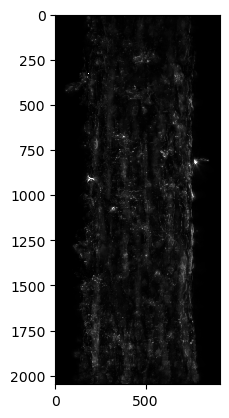

In [5]:
stackview.imshow(cnx_img, axes= True)

#### Image Analysis and Display

In [7]:
print("shape: {}".format(cnx_img.shape)) 
print("dtype: {}".format(cnx_img.dtype))
print("range: ({}, {})".format(np.min(cnx_img), np.max(cnx_img)))

# shape: (510, 2048, 912) = (plane, row, column) 
# dtype: uint16
# range: (0, 65530) pixels go from darkest to almost brightest possible (would be 2^16 - 1 = 65535)

shape: (2048, 912)
dtype: uint16
range: (0, 43671)


In [9]:
viewer = napari.view_image(cnx_img)

C:\Users\laura\AppData\Local\Temp\ipykernel_21732\629757579.py:1: FutureWarning: `napari.view_image` is deprecated and will be removed in napari 0.7.0.
Use `viewer = napari.Viewer(); viewer.add_image(...)` instead.
  viewer = napari.view_image(cnx_img)


### Selecting a plane from the image

In [8]:
# saving the plane as image
import imageio


imageio.imwrite('test_plane_254.tiff', cnx_img[254])

### Histogram

In [10]:
# plotting histogram 
def plot_hist(ax, data, title=None): #helper function
    ax.hist(data.ravel(), bins=256)
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
    
    if title:
        ax.set_title(title)

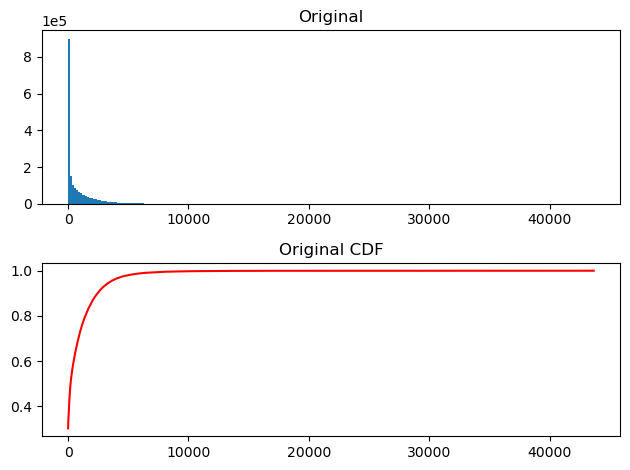

In [ ]:
equalized = exposure.equalize_hist(cnx_img)

fig, (a, b) = plt.subplots(nrows=2, ncols=1)

plot_hist(a, cnx_img, title="Original")

cdf, bins = exposure.cumulative_distribution(cnx_img.ravel())
b.plot(bins, cdf, "r")
b.set_title("Original CDF")

fig.tight_layout()

### Image Deblurring

c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\stackview\_imshow.py:58: UserWarning: The parameter min_display_intensity is deprecated, use min_display_intensity instead.
  warnings.warn("The parameter min_display_intensity is deprecated, use min_display_intensity instead.")
c:\Users\laura\miniconda3\envs\cardiac_analysis\Lib\site-packages\stackview\_imshow.py:62: UserWarning: The parameter max_display_intensity is deprecated, use max_display_intensity instead.
  warnings.warn("The parameter max_display_intensity is deprecated, use max_display_intensity instead.")


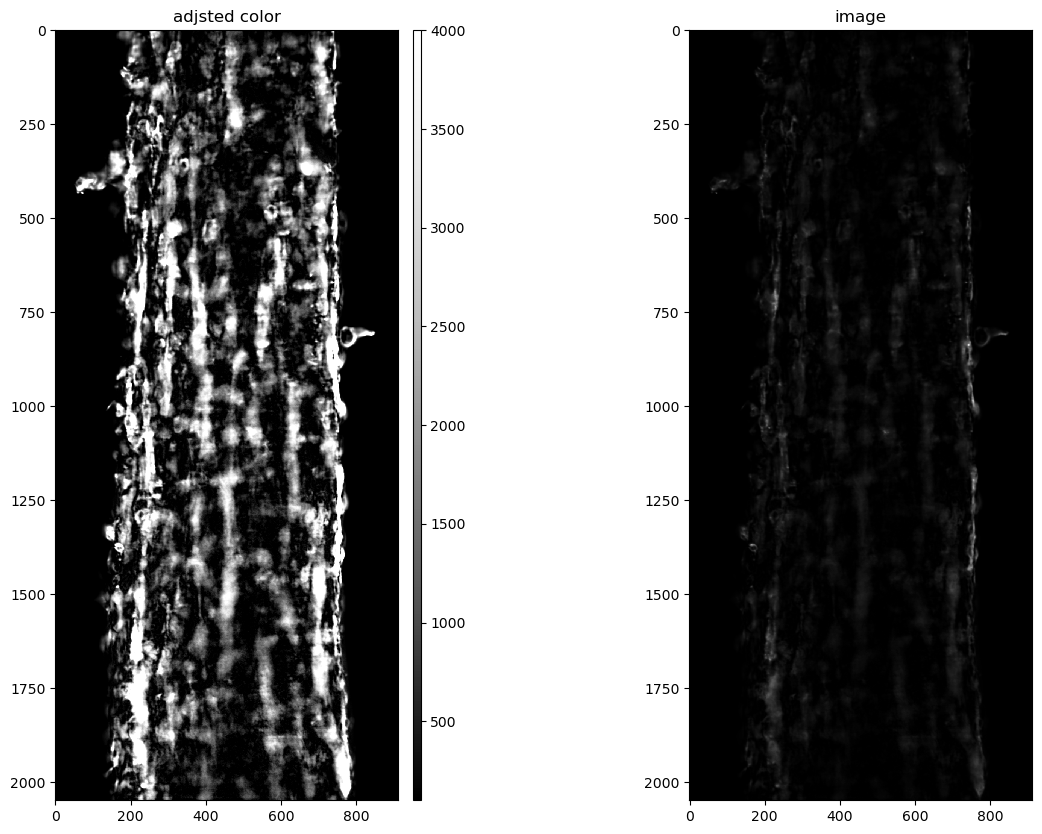

In [46]:
# plot multiple images
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15,10))

stackview.imshow(cnx_img, plot=axs[0], title='adjsted color', axes = True, colorbar=True, vmin=100, vmax=4000)
stackview.imshow(cnx_img, plot=axs[1], title='image', axes=True)

### Testing Deconvolution with PDf 
https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/18a_deconvolution/introduction_deconvolution.html

##### Construct PSF

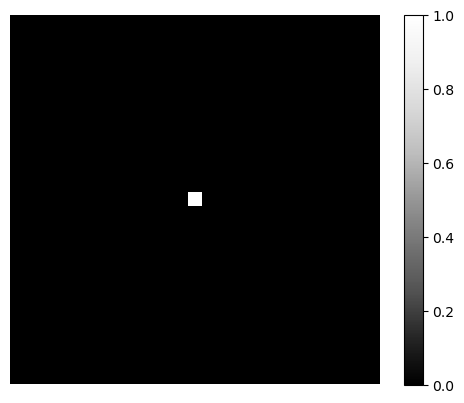

In [43]:
# construct an artificial PSF (point spread function) image
perfect_psf = np.zeros( (25,25) )
perfect_psf[12, 12] = 1

stackview.imshow(perfect_psf, colorbar=True)

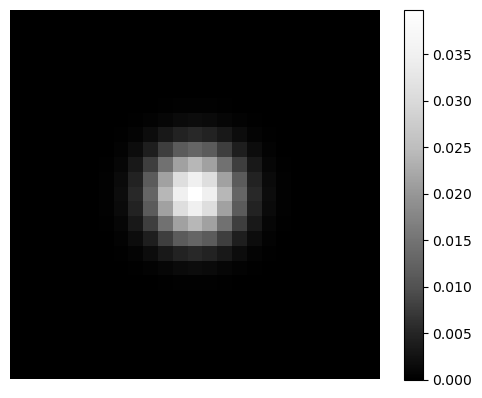

In [44]:
from skimage.filters import gaussian
psf = gaussian(perfect_psf, sigma=2)
stackview.imshow(psf, colorbar=True)

In [ ]:
# goal is to have an image where the toal intensity is 1 - to make sure that
# an image that is deconvolved using this PSF later on does not modify the image's intensity range
normalized_psf = avg_psf_image / np.sum(avg_psf_image)

imshow(normalized_psf, colorbar=True)

#### Convolution

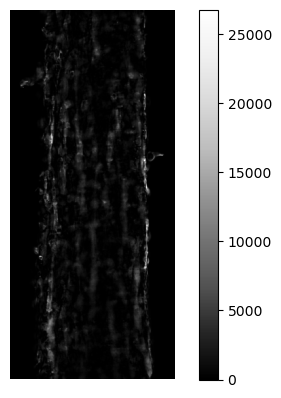

In [55]:
from scipy.ndimage import convolve
convolved = convolve(cnx_img, psf)

stackview.imshow(convolved, colorbar=True)

#### Deconvolution

In [48]:
from napari_simpleitk_image_processing import richardson_lucy_deconvolution
number_of_iterations = 10
deconvolved = richardson_lucy_deconvolution(convolved, psf, number_of_iterations)


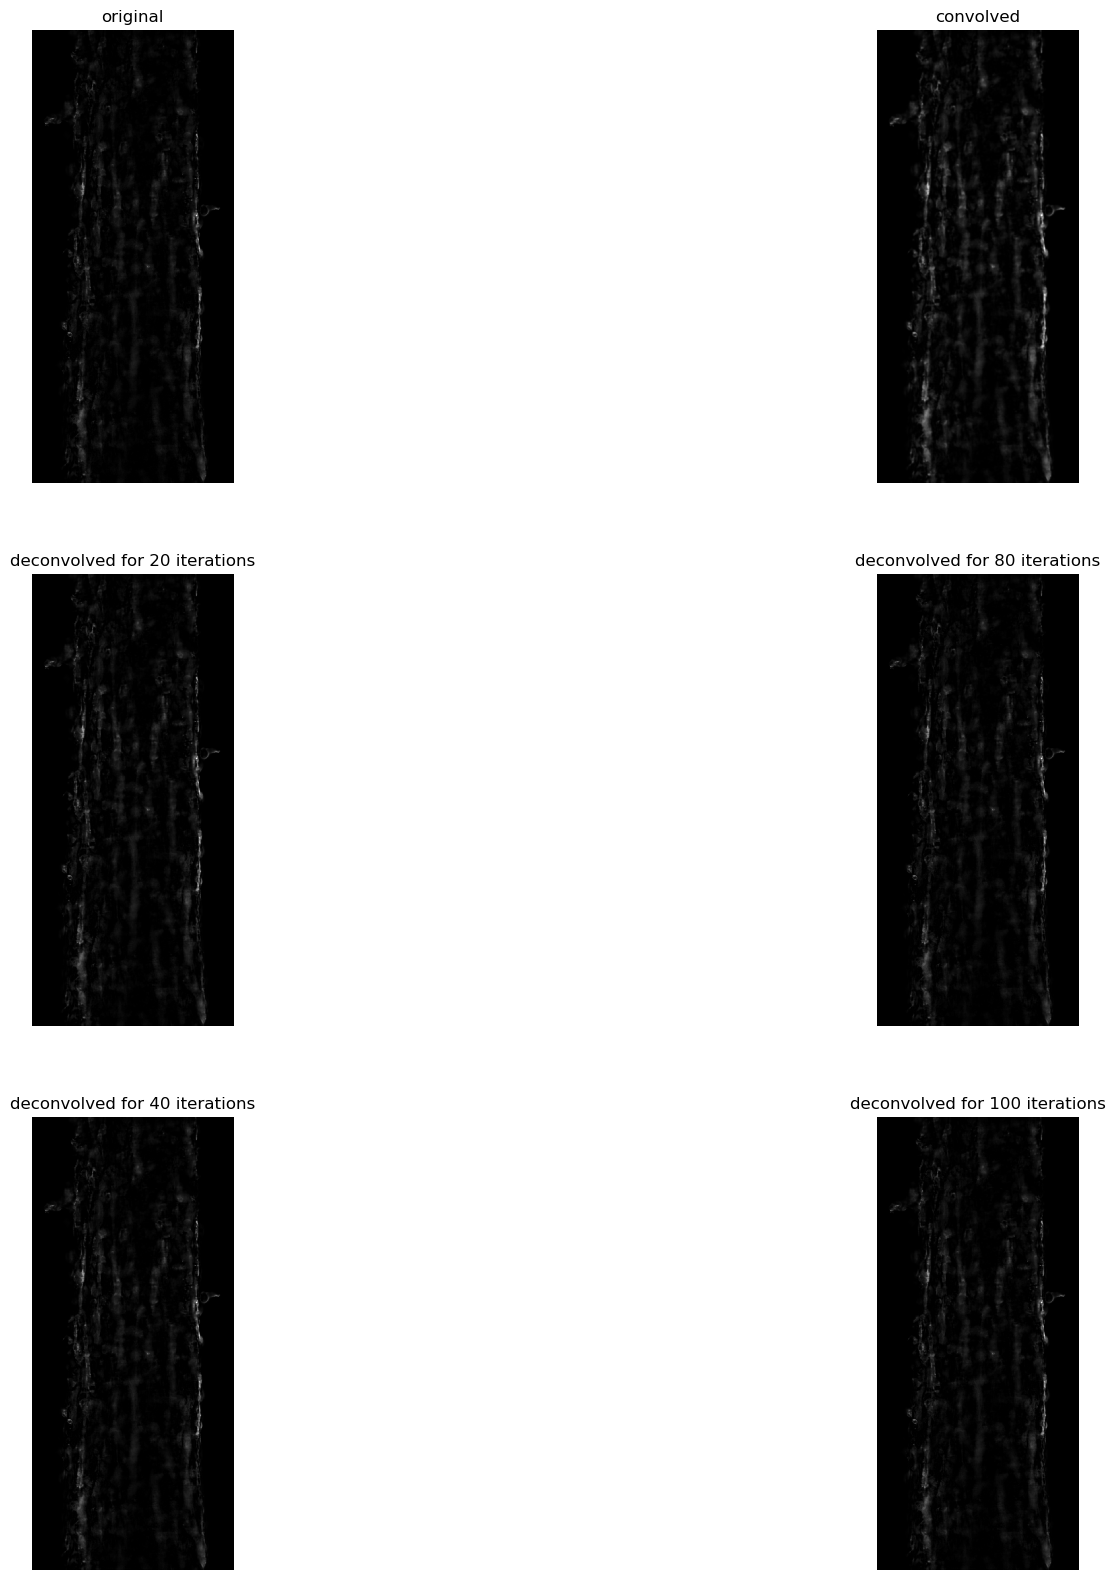

In [50]:
fig, axs = plt.subplots(3, 2, figsize=(20,20))

stackview.imshow(cnx_img, plot=axs[0, 0])
axs[0,0].set_title("original")

stackview.imshow(convolved, plot=axs[0, 1])
axs[0,1].set_title("convolved")

for i, number_of_iterations in enumerate([20, 40, 80, 100]):

    deconvolved = richardson_lucy_deconvolution(convolved, psf, number_of_iterations)

    axis = axs[(i) % 2 + 1, int((i) / 2)]
    stackview.imshow(deconvolved, plot=axis)
    
    axis.set_title("deconvolved for " + str(number_of_iterations) + " iterations")

### Segmentation of Convolved Image

In [52]:
import pyclesperanto_prototype as cle

# hier weiter: https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/20_image_segmentation/09a_gauss_otsu_labeling.html

In [53]:
#apply segmentation to deconvolved image
sigma_outline = 1

segmented = cle.gauss_otsu_labeling(deconvolved, outline_sigma=sigma_outline)

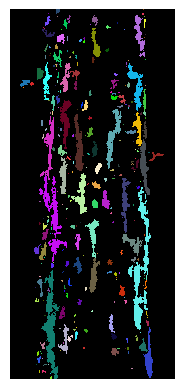

In [54]:
stackview.imshow(segmented)

### Determining the point-spread-function from a bead image by averaging
https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/18a_deconvolution/extract_psf.html

https://blog.biodock.ai/image-deconvolution/ - contiue here